In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('future.no_silent_downcasting', True)

df = pd.read_csv(r"C:\Users\matab\OneDrive\Desktop\Praca\vscode-jupyter\project2-otodom-analysis\data\Otodom_Flat_Listings.csv")
print(df)

                                                  Title      Price  \
0        2 pokoje 47m2 po remoncie + garderoba + balkon   415000.0   
1     Właściciel- Ludwiki DD - WIDOK NA ZIELEŃ - 2x gar  2499000.0   
2        Sprzedam mieszkanie 60m2, 2 balkony, garderoba   649000.0   
3                Wyjątkowy, duży apartament z antresolą  2108000.0   
4     2/3-pok. 49,2 m2 w samym sercu Koszalina - Kuncer   450180.0   
...                                                 ...        ...   
2802           Apartament Gąski - gotowiec inwestycyjny   525000.0   
2803           3 pok | Garaż | SMARTHOME | Klimatyzacja   829000.0   
2804  Mieszkanie 3 pokojowe na Woli w super lokalizacji   830000.0   
2805  Rozkładowe, blisko uczelni, Wrocław, Sienkiewicza   699000.0   
2806  Mieszkanie 3 pok. + 2 miejsca parkingowe Obrzeżna  1450000.0   

                                               Location  Surface  \
0     ul. Marysińska, Stare Bałuty, Bałuty, Łódź, łó...    47.00   
1      ul. Ludwiki, Czy

C:\Users\matab\AppData\Local\Temp\ipykernel_4728\1316369048.py:4: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [2]:
df.info()
df.isnull().sum()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 2807 entries, 0 to 2806
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Title                   2807 non-null   str    
 1   Price                   2664 non-null   float64
 2   Location                2806 non-null   str    
 3   Surface                 2807 non-null   float64
 4   Number_of_Rooms         2807 non-null   str    
 5   Floor                   2743 non-null   str    
 6   Finishing_Condition     2229 non-null   str    
 7   Heating                 2060 non-null   str    
 8   Parking_Space           1478 non-null   str    
 9   Balcony_Garden_Terrace  2102 non-null   str    
 10  Link                    2807 non-null   str    
 11  Voivodeship             2806 non-null   str    
 12  City                    2806 non-null   str    
dtypes: float64(2), str(11)
memory usage: 942.1 KB


(2807, 13)

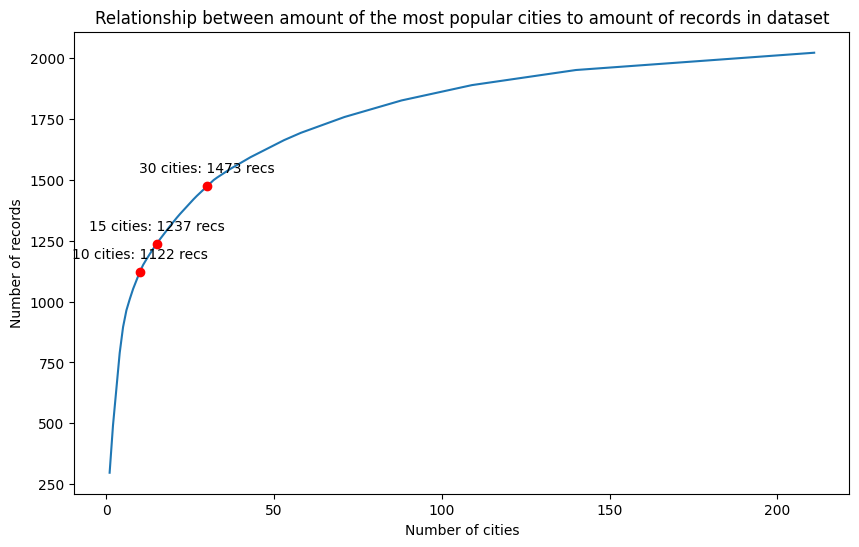

In [3]:
# Cleaning data
df = df.dropna(subset=['Price'])
df = df.dropna(subset=["Floor"])
df = df.dropna(subset=["Finishing_Condition"])
df = df.dropna(subset=["Location"])

df = df[(df["Price"] > 10000) & (df["Price"] < 5000000)]

df["Number_of_Rooms"] = df["Number_of_Rooms"].astype(str).str.strip()
df["Number_of_Rooms"] = df["Number_of_Rooms"].str.replace("więcej niż 10", "11")
df["Number_of_Rooms"] = pd.to_numeric(df["Number_of_Rooms"], errors='coerce')

df["Floor"] = df["Floor"].str.strip()
df["Floor"] = df["Floor"].str.replace("parter", "0")
df["Floor"] = df["Floor"].str.replace("sutenera", "-1")
df["Floor"] = df["Floor"].str.replace("suterena", "-1")
df["Floor"] = df["Floor"].str.replace("> 10", "11")

new_columns_floor = df["Floor"].str.split("/", expand=True)
df["Floor_level"] = new_columns_floor[0]
df["Floor_total"] = new_columns_floor[1]
df["Floor_level"] = np.where(df["Floor_level"] == 'poddasze', df["Floor_total"], df["Floor_level"])
df["Floor_level"] = pd.to_numeric(df["Floor_level"], errors="coerce")
df["Floor_total"] = pd.to_numeric(df["Floor_total"], errors="coerce")
med = df["Floor_total"].median()
smart_replacement = pd.Series(np.where(df["Floor_level"] > med, df["Floor_level"], med), index=df.index)
df["Floor_total"] = df["Floor_total"].fillna(smart_replacement)

## Manual one-hot encoding
df["Parking_Space"] = df["Parking_Space"].notna().astype(int)
df["Balcony"] = df["Balcony_Garden_Terrace"].str.contains("balkon", case=False).fillna(False).astype(int)
df["Garden"] = df["Balcony_Garden_Terrace"].str.contains("ogródek", case=False).fillna(False).astype(int)
df["Terrace"] = df["Balcony_Garden_Terrace"].str.contains("taras", case=False).fillna(False).astype(int)

## Probabilistic imputation
chances = df["Heating"].value_counts(normalize=True)
quantity = df["Heating"].isnull().sum()
picks = np.random.choice(a=chances.index, p=chances.values, size=quantity)
df.loc[df["Heating"].isnull(), "Heating"] = picks

# Creating a chart - cumulative distribution for checking the elbow point of city frequency to decide if one should group the long tail or use alternative encoding
city_counts = df["City"].value_counts()
cumulative_records = city_counts.cumsum().values
plt.figure(figsize=(10,6))
milestones = [10, 15, 30]
for m in milestones:
    if m <= len(cumulative_records):
        val = cumulative_records[m-1]
        plt.scatter(m, val, color='red', zorder=3)
        plt.annotate(f'{m} cities: {val} recs', (m, val), textcoords="offset points", xytext=(0,10), ha='center')
plt.plot(range(1, len(cumulative_records) + 1), cumulative_records)
plt.xlabel("Number of cities")
plt.ylabel("Number of records")
plt.title("Relationship between amount of the most popular cities to amount of records in dataset")
plt.show()

## Conclusion: the long tail that is small cities are too big to ignore, beacuse it account for 27% of dataset so I'll use the target encoding


Linear regression results
MAE =  166761.73281448486 
       Real price  Predicted price
939     620000.0    444010.482347
1919    601000.0    577466.476954
993     290000.0    351354.892080
812     353000.0    574780.335042
795     609000.0    646398.357947 

Random forest results
MAE =  148618.94560493826 
       Real price  Predicted price
939     620000.0        553343.76
1919    601000.0        590510.98
993     290000.0        348493.50
812     353000.0        545370.06
795     609000.0        675885.66 



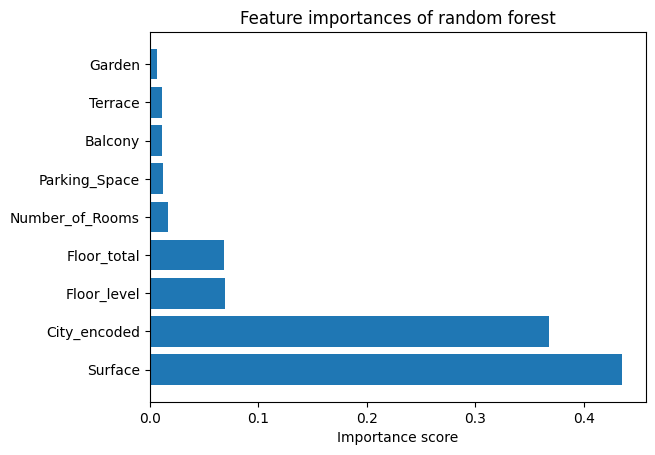

,City_name,Price,Surface,Error
2529,Warszawa,3698672.00,149.14,1989994.42
1213,Warszawa,1340000.00,130.00,1978913.57
2595,Świnoujście,750000.00,82.44,1609541.38
2638,Warszawa,2250000.00,71.00,1276008.72
434,Warszawa,1599000.00,125.00,1119174.74


In [47]:
# Applying ml model

## Target encoding
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
city_means = train_df.groupby("City")["Price"].mean()
global_mean = train_df["Price"].mean()
train_df["City_encoded"] = train_df["City"].map(city_means)
test_df["City_encoded"] = test_df["City"].map(city_means)
test_df["City_encoded"] = test_df["City_encoded"].fillna(global_mean)
train_df = train_df.drop("City", axis=1)
test_df = test_df.drop("City", axis=1)

## Linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

y_train = train_df["Price"]
y_test = test_df["Price"]
X_train = train_df.select_dtypes(include=['number']).drop("Price", axis=1)
X_test = test_df.select_dtypes(include=['number']).drop("Price", axis=1)

model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

results = pd.DataFrame({'Real price': y_test, 'Predicted price': predictions})
print("Linear regression results\nMAE = ", mae, "\n", results.head(), "\n")

## Random forest
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)
forest_preds = forest_model.predict(X_test)
forest_mae = mean_absolute_error(y_test, forest_preds)

forest_results = pd.DataFrame({'Real price': y_test, 'Predicted price': forest_preds})
print("Random forest results\nMAE = ", forest_mae, "\n", forest_results.head(), "\n")

## Feature importances of random forest
importances = forest_model.feature_importances_
feature_names = X_train.columns
feature_rank = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feature_rank = feature_rank.sort_values(by="Importance", ascending=False)

plt.barh(feature_rank["Feature"], feature_rank["Importance"])
plt.title("Feature importances of random forest")
plt.xlabel("Importance score")
# plt.xticks(rotation=45, ha='right')
plt.show()

## Figuring out high mae
test_df["Error"] = abs(y_test - forest_preds)
biggest_fails = test_df.sort_values(by="Error", ascending=False).head(5)
report = biggest_fails[["Price", "Surface", "Error"]].copy()
report["City_name"] = df.loc[biggest_fails.index, "City"]
report = report[["City_name", "Price", "Surface", "Error"]]
pd.options.display.float_format = '{:.2f}'.format
report